In [121]:
from utils import *
import pandas as pd
import glob, os

In [122]:
def safe_map(func):
    def wrapper(x):
        try:
            return func(x)
        except Exception:
            return None

    return wrapper

In [123]:
dfs = []
for file in glob.glob(f"../results/experiment*scaling*.csv"):
    dfs.append(pd.read_csv(file))
df = pd.concat(dfs, ignore_index=True)
for col in df.columns:
    if col.endswith("times"):
        df[col] = df[col].apply(safe_map(ast.literal_eval))
df["metadata"] = df["metadata"].apply(safe_map(ast.literal_eval))
df["solvers m"] = df["solvers m"].apply(lambda m: "-" if pd.isna(m) else m)
df["coarse m"] = df["coarse m"].apply(lambda m: "-" if pd.isna(m) else m)
df["p"] = df["p"].apply(int)

In [124]:
def nice_solver_name(name):
    if "AMGX" in name:
        return "AmgX"
    if "Hybrid" in name:
        return "Hybrid Schwarz"
    if "Additive" in name:
        return "Additive Schwarz"
    return None

In [125]:
df["best solve time"] = df["solve times"].apply(min)
df["best DoFs/s"] = df.apply(
    lambda row: row["DoFs"] / row["best solve time"],
    axis=1,
)
df["nice solver"] = df["solver"].apply(nice_solver_name)
df["fine m val"] = df["fine m"].apply(lambda m: int(m[1:]))

In [137]:
pivot = df.pivot_table(
    values="best DoFs/s",
    index=["p", "solver"],
    columns=["DoFs"]
)
pivot

DoFs                                                     5120        6144     \
p solver                                                                       
1 AMGX(CG_L1_TRUNC, None)                                    NaN  940.982727   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)                 NaN  452.059343   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)                  NaN  175.987437   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...         NaN  454.903002   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)         NaN  183.059372   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...         NaN  216.802905   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...         NaN   93.343216   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...         NaN  378.997978   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...         NaN  159.869304   
3 AMGX(CG_L1_TRUNC, None)                             420.585565         NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          214.081766         NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)            87.029741         NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  225.827935         NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)   89.029456         NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   89.124572         NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...   38.358422         NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  150.892580         NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...   63.165160         NaN   

DoFs                                                     20480        24576    \
p solver                                                                        
1 AMGX(CG_L1_TRUNC, None)                                    NaN  2569.128863   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)                 NaN  1388.464492   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)                  NaN   625.350626   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...         NaN  1487.363305   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)         NaN   641.436820   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...         NaN   695.491555   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...         NaN   326.168108   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...         NaN  1336.598235   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...         NaN   603.704751   
3 AMGX(CG_L1_TRUNC, None)                             976.724911          NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)          634.474992          NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)           301.521704          NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...  647.163452          NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)  309.630778          NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  242.841119          NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...  129.752992          NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  475.050584          NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...  239.045739          NaN   

DoFs                                                      81920    \
p solver                                                            
1 AMGX(CG_L1_TRUNC, None)                                     NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=False)                  NaN   
  CG(AMGX(L1_TRUNC, None), bsr_matmul=True)                   NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=Fa...          NaN   
  CG(AMGX(L1_TRUNC, torch.float32), bsr_matmul=True)          NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...          NaN   
  CG(AdditiveSchwarz(torch.float32, Inv(torch.flo...          NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...          NaN   
  CG(HybridSchwarz(torch.float64, Inv(torch.float...          NaN   
3 AMGX(CG_L1_TRUNC,

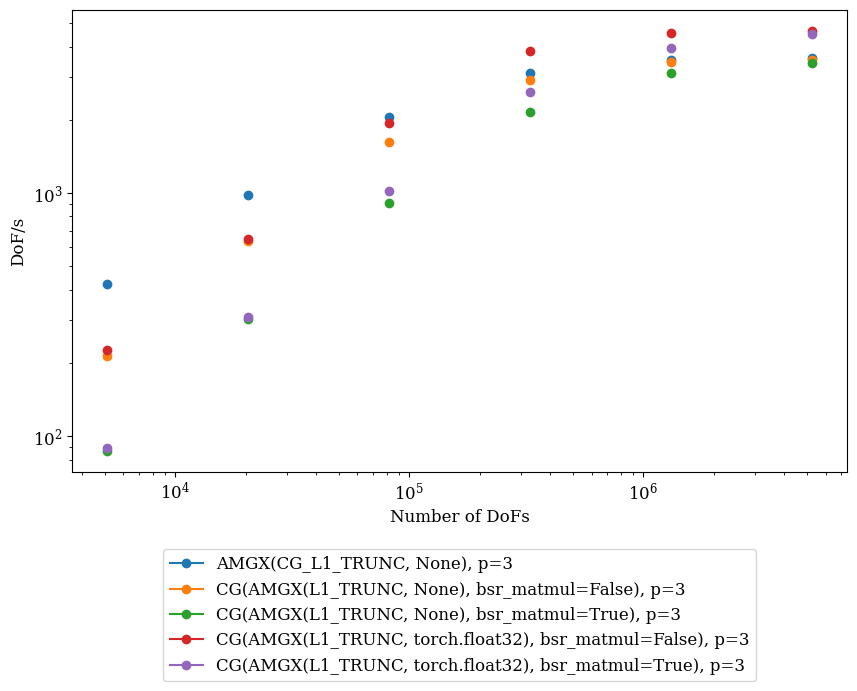

In [148]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_yscale("log")
ax.set_xscale("log")
for (p, solver), vals in pivot.iterrows():
    if p != 3:
        continue
    if "AMGX" not in solver:
        continue
    ax.plot(vals, label=f"{solver}, p={p}", marker='o')
ax.set_ylabel("DoF/s")
ax.set_xlabel("Number of DoFs")

#legend below the plot
ax.legend(bbox_to_anchor=(0.5, -0.15), loc="upper center", ncol=1)

fig.show()